In [1]:
from scipy.stats import spearmanr
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots
import seaborn as sns

In [2]:
RESULTS_DF = "../data/results.parquet"

In [3]:
df = pd.read_parquet(RESULTS_DF)
df["status"] = df["status"].replace({"timeout (600 seconds)": "timeout"})

In [4]:
# Use output_ebit_count if available, otherwise fallback to distribution_cost (which is reported in some timeout executions)
df["partition_ebit_cost"] = df["output_ebit_count"].fillna(df["distribution_cost"])

# Filter out failed and timeout executions (those that did not report a "distribution_cost")
df = df[df["partition_ebit_cost"].notna()]

In [5]:
# Columns that describe the experiment run
METADATA_COLS = [
    "benchmark",
    "network_topology",
    "num_qpus",
    "partitioner",
    "circuit",
    "n_qubits",
    "status",
]

In [6]:
# Columns that describe the circuit metrics (input and output)
CIRCUIT_METRICS = [
    "circuit_depth",
    "circuit_width",
    ##
    "gate_density",
    "measurement_density",
    "entanglement_variance",
    ##
    "communication_supermarq",
    "critical_depth_supermarq",
    "entanglement_ratio_supermarq",
    "parallelism_supermarq",
    "liveness_supermarq",
    "measurement_supermarq",
    ##
    "gate_node_count",
    "measurement_count",
    ##
    "maximum_dual_qubit_count",
    "maximum_qubit_depth_id",
    "maximum_qubit_depth",
    ##
    "dual_gate_count",
    ##
    "gate_count",
    "size_factor",
    "single_gate_count",
    "dag_depth",
    "qubit_count",
    ##
    "ebit_count",
]

METRICS_TO_DROP = [
    "qubit_count",  # Is equal to circuit_width
    "size_factor",  # Is log of gate_count
    "dag_depth",  # Is equal to circuit_depth
    "retention_lifespan",  # Is log of circuit_depth # TODO
    "gate_count",  # Is very correlated with gate_node_count, but "gate_count for a single-qubit gate counts as 1, a two-qubit gate counts as 2, and so on."
    "single_gate_count",  # I'm not so interested # TODO
    # "double_gate_count",  # TODO
    "dual_gate_count",  # TODO
    "ebit_count",  # Already tracked as target variable, and not relevant for input_
    ##
    "liveness_supermarq",  # Very correlated with gate_density
    "critical_depth_supermarq",  # Inversely correlated with parallelism_supermarq
    "communication_supermarq",  # Lots of NaNs and low correlation
    # "entanglement_ratio_supermarq",  # Lots of NaNs and low correlation, very similar to entanglement_variance
    ##
    "maximum_dual_gate_count",
    "maximum_dual_qubit_count",
    "maximum_qubit_depth_id",
    "maximum_qubit_depth",
    ##
    "measurement_density",  # Already have measurement_count
    "measurement_supermarq",  # Already have measurement_count
    "measurement_count",  # Already have measurement_count
    ##
]

CIRCUIT_METRICS = [m for m in CIRCUIT_METRICS if m not in METRICS_TO_DROP]


In [7]:
# Input metrics
INPUT_METRICS = [f"input_{metric}" for metric in CIRCUIT_METRICS]

# Extract all output metrics
OUTPUT_METRICS = [f"output_{metric}" for metric in CIRCUIT_METRICS]

In [8]:
# Create 'Delta' metrics to measure the structural penalty of the partitioner
DELTA_METRICS = CIRCUIT_METRICS

for metric in DELTA_METRICS:
    input_col = f"input_{metric}"
    output_col = f"output_{metric}"
    delta_col = f"delta_{metric}"

    # Compute the difference between output and input metrics
    df[delta_col] = df[output_col] - df[input_col]


In [9]:
# Define our key targets
TARGET_METRICS = [
    *[f"delta_{metric}" for metric in DELTA_METRICS],
    ##
    "partition_ebit_cost",
    ##
    "partition_exec_time_s",
]

In [10]:
df = df[METADATA_COLS + INPUT_METRICS + OUTPUT_METRICS + TARGET_METRICS]

In [11]:
# Initialize dataframes to store correlation coefficients and p-values
corr_matrix = pd.DataFrame(index=INPUT_METRICS, columns=TARGET_METRICS)
pval_matrix = pd.DataFrame(index=INPUT_METRICS, columns=TARGET_METRICS)

# Calculate Spearman correlation and p-value for each pair
for x in INPUT_METRICS:
    for y in TARGET_METRICS:
        # Drop NaNs for the specific pair to avoid math errors
        valid_data = df[[x, y]].dropna()
        if len(valid_data) > 1:
            r, p = spearmanr(valid_data[x], valid_data[y])
            corr_matrix.loc[x, y] = r
            pval_matrix.loc[x, y] = p
        else:
            corr_matrix.loc[x, y] = np.nan
            pval_matrix.loc[x, y] = np.nan

# Convert to float
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

# Mask correlations that are not statistically significant (p > 0.05) OR are very weak (between -0.2 and 0.2)
mask = (pval_matrix > 0.05) | (corr_matrix.abs() < 0.2)

# Sort rows by 'partition_ebit_cost'
corr_matrix_sorted = corr_matrix.sort_values(by="partition_ebit_cost", ascending=False)

# Reorder columns to match the exact row sequence of base variables
sorted_base_names = [row.replace("input_", "") for row in corr_matrix_sorted.index]
sorted_delta_cols = [f"delta_{base}" for base in sorted_base_names if f"delta_{base}" in corr_matrix.columns]
other_target_cols = [col for col in corr_matrix.columns if col not in sorted_delta_cols]
# final_column_order = sorted_delta_cols + ["partition_ebit_cost"]
# final_column_order = sorted_delta_cols + other_target_cols
final_column_order = sorted_delta_cols + ["partition_exec_time_s", "partition_ebit_cost"]

# Apply the synchronized row and column index order
corr_matrix_sorted = corr_matrix_sorted.reindex(columns=final_column_order)
mask_sorted = mask.loc[corr_matrix_sorted.index, corr_matrix_sorted.columns]

In [12]:
COLS_TO_REMOVE = [
    "delta_circuit_width",
    "delta_measurement_count",
]

corr_matrix_final = corr_matrix_sorted.drop(columns=COLS_TO_REMOVE, errors="ignore").drop(index=COLS_TO_REMOVE, errors="ignore")
mask_final = mask_sorted.drop(columns=COLS_TO_REMOVE, errors="ignore").drop(index=COLS_TO_REMOVE, errors="ignore")

In [13]:
LABEL_MAPPING = {
    "input_gate_node_count": "Gate Count",
    "input_parallelism_supermarq": "Parallelism",
    "input_circuit_depth": "Circuit Depth",
    "input_circuit_width": "Circuit Width",
    "input_gate_density": "Gate Density",
    "input_entanglement_ratio_supermarq": "Entang. Ratio",
    "input_entanglement_variance": "Entang. Var.",
    ##
    "delta_circuit_depth": r"$\Delta$ Circuit Depth",
    "delta_circuit_width": r"$\Delta$ Circuit Width",
    "delta_gate_density": r"$\Delta$ Gate Density",
    "delta_entanglement_variance": r"$\Delta$ Entang. Var.",
    "delta_entanglement_ratio_supermarq": r"$\Delta$ Entang. Ratio",
    "delta_parallelism_supermarq": r"$\Delta$ Parallelism",
    "delta_gate_node_count": r"$\Delta$ Gate Count",
    "partition_ebit_cost": "E-bit Cost",
    "partition_exec_time_s": "Exec Time (s)",
}

corr_matrix_renamed = corr_matrix_final.rename(
    index=LABEL_MAPPING, columns=LABEL_MAPPING
)
mask_renamed = mask_final.rename(index=LABEL_MAPPING, columns=LABEL_MAPPING)

In [14]:
# Plotting configuration
plt.style.use(["science", "ieee"])
matplotlib.rcParams.update(
    {
        "font.family": "serif",
        "text.usetex": True,
    }
)

COLUMN_WIDTH = 3
BETWEEN_COLUMN_SPACING = 0.14
# ASPECT_RATIO = 2/3
ASPECT_RATIO = 1
SCALE = 1.0
FIGURE_WIDTH = COLUMN_WIDTH * SCALE
FIGURE_HEIGHT = FIGURE_WIDTH * ASPECT_RATIO

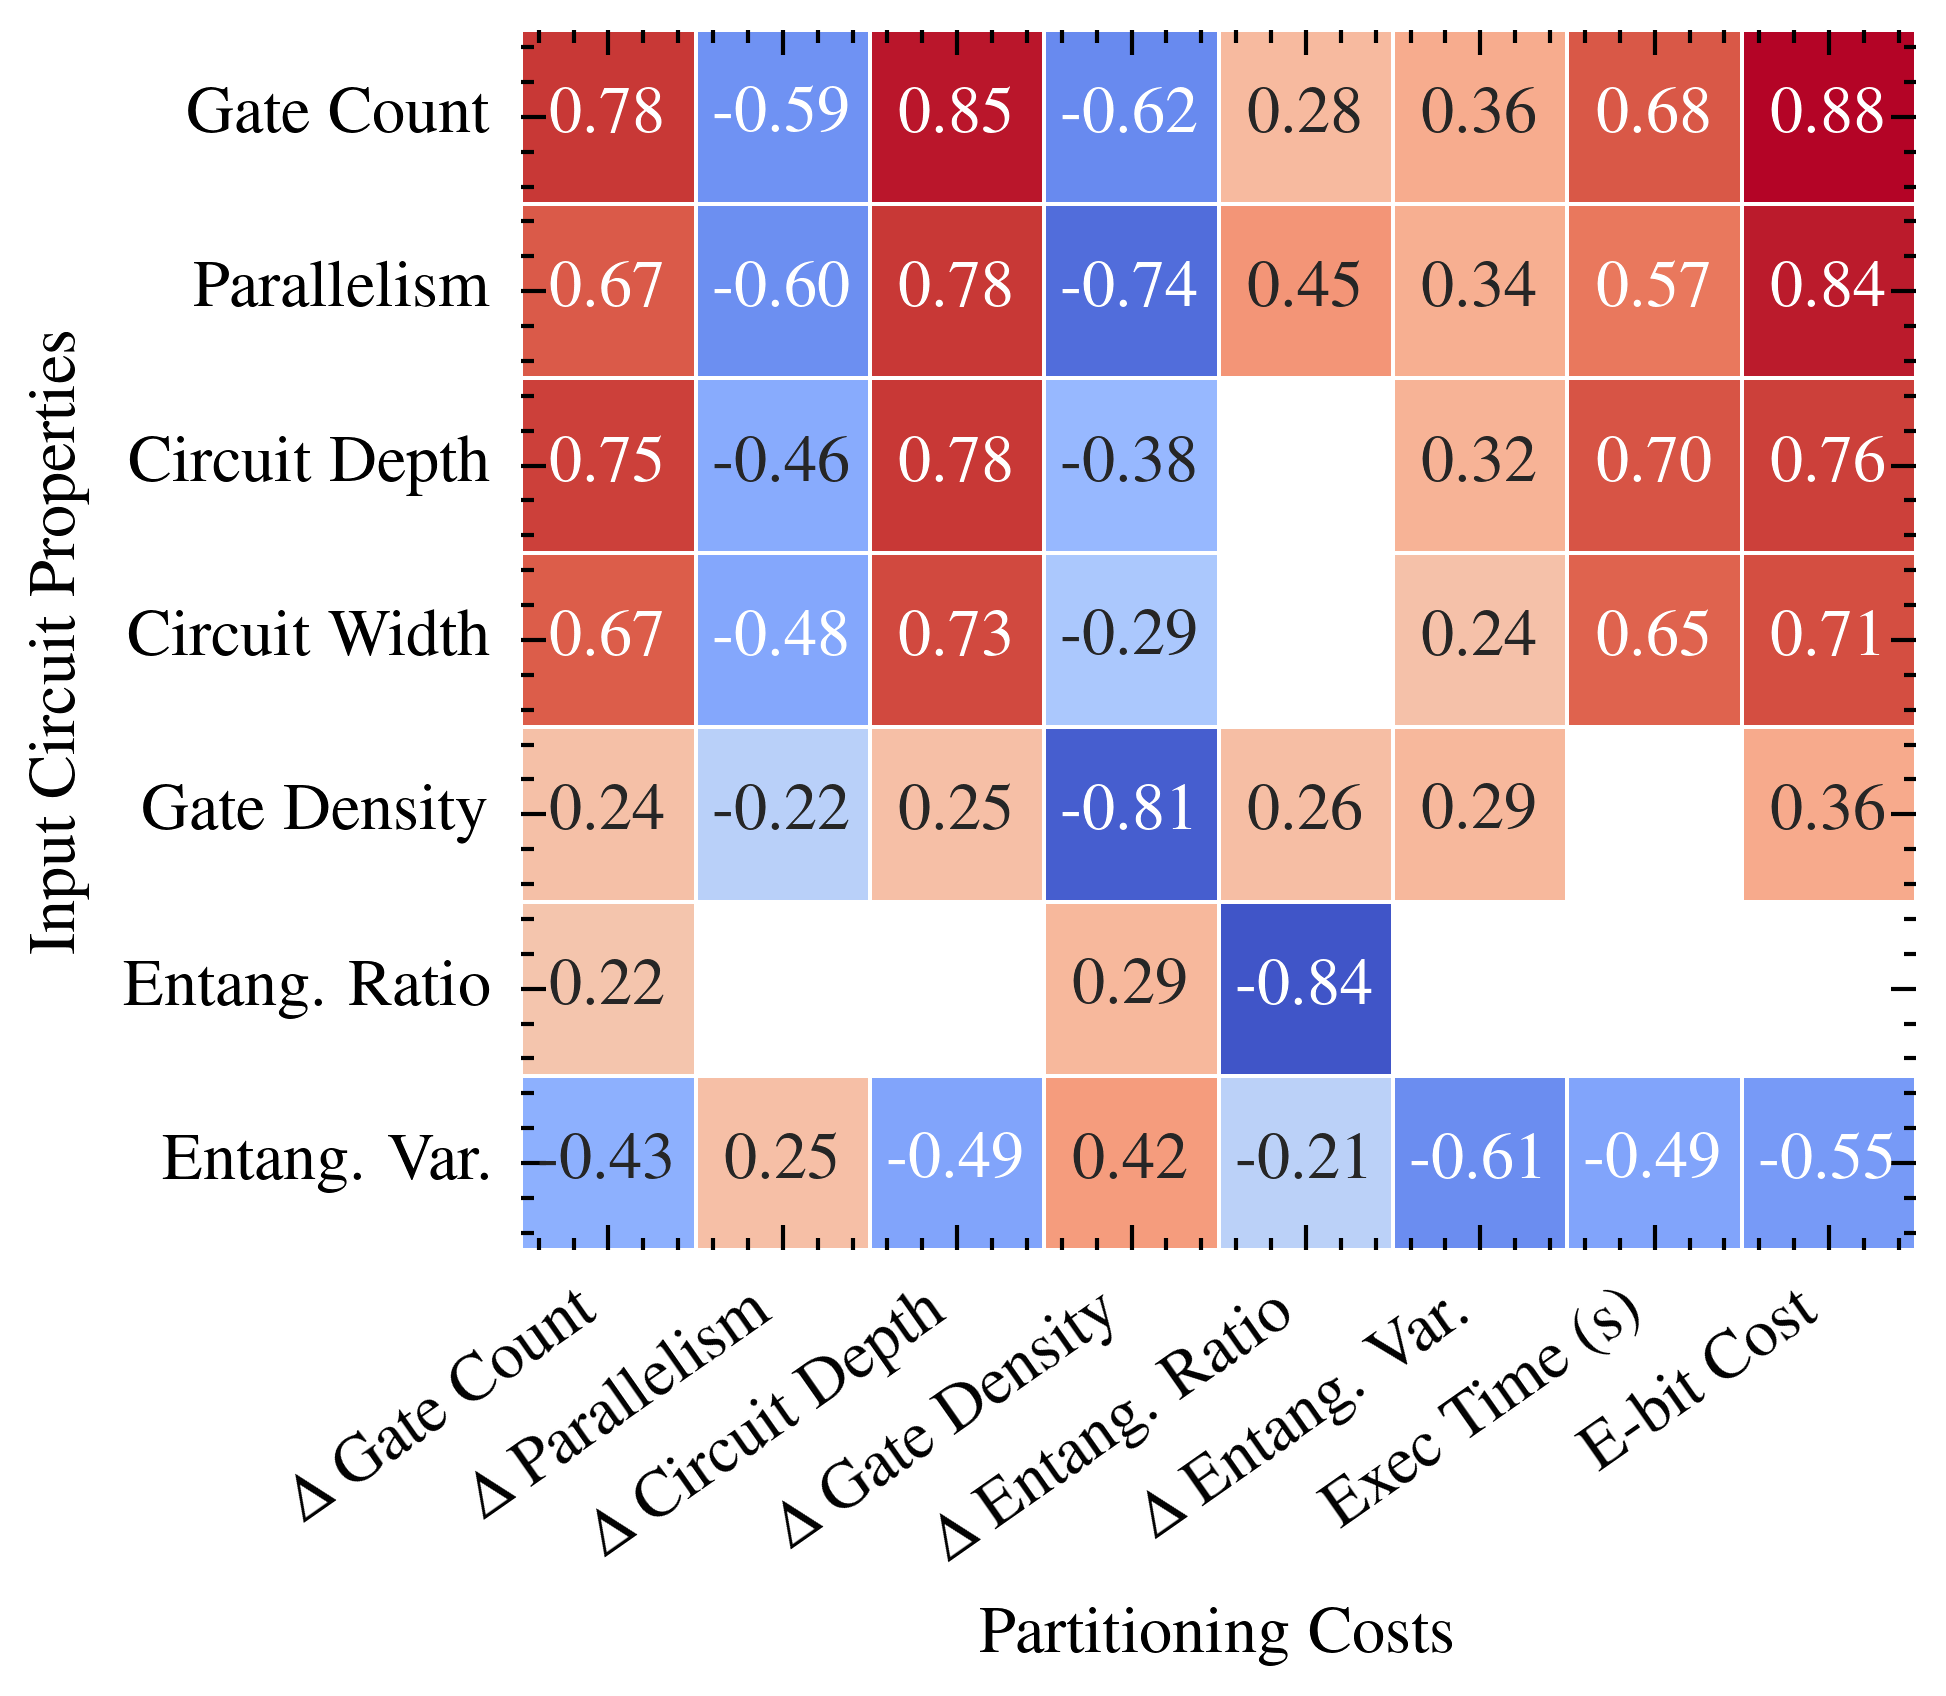

In [15]:
# Plotting the heatmap
plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
sns.heatmap(
    corr_matrix_renamed,
    mask=mask_renamed,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    cbar=False,
    # cbar_kws={
    #     "label": "Spearman Correlation",
    #     "shrink": 0.7,
    # },
    linewidths=0.25,
    # annot_kws={"size": 6}
)
plt.grid(False)
plt.xlabel("Partitioning Costs")
plt.ylabel("Input Circuit Properties")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0) # 35, ha="right", va="top", )

plt.savefig("figures/correlation.pdf", bbox_inches="tight", dpi=300)
plt.show()